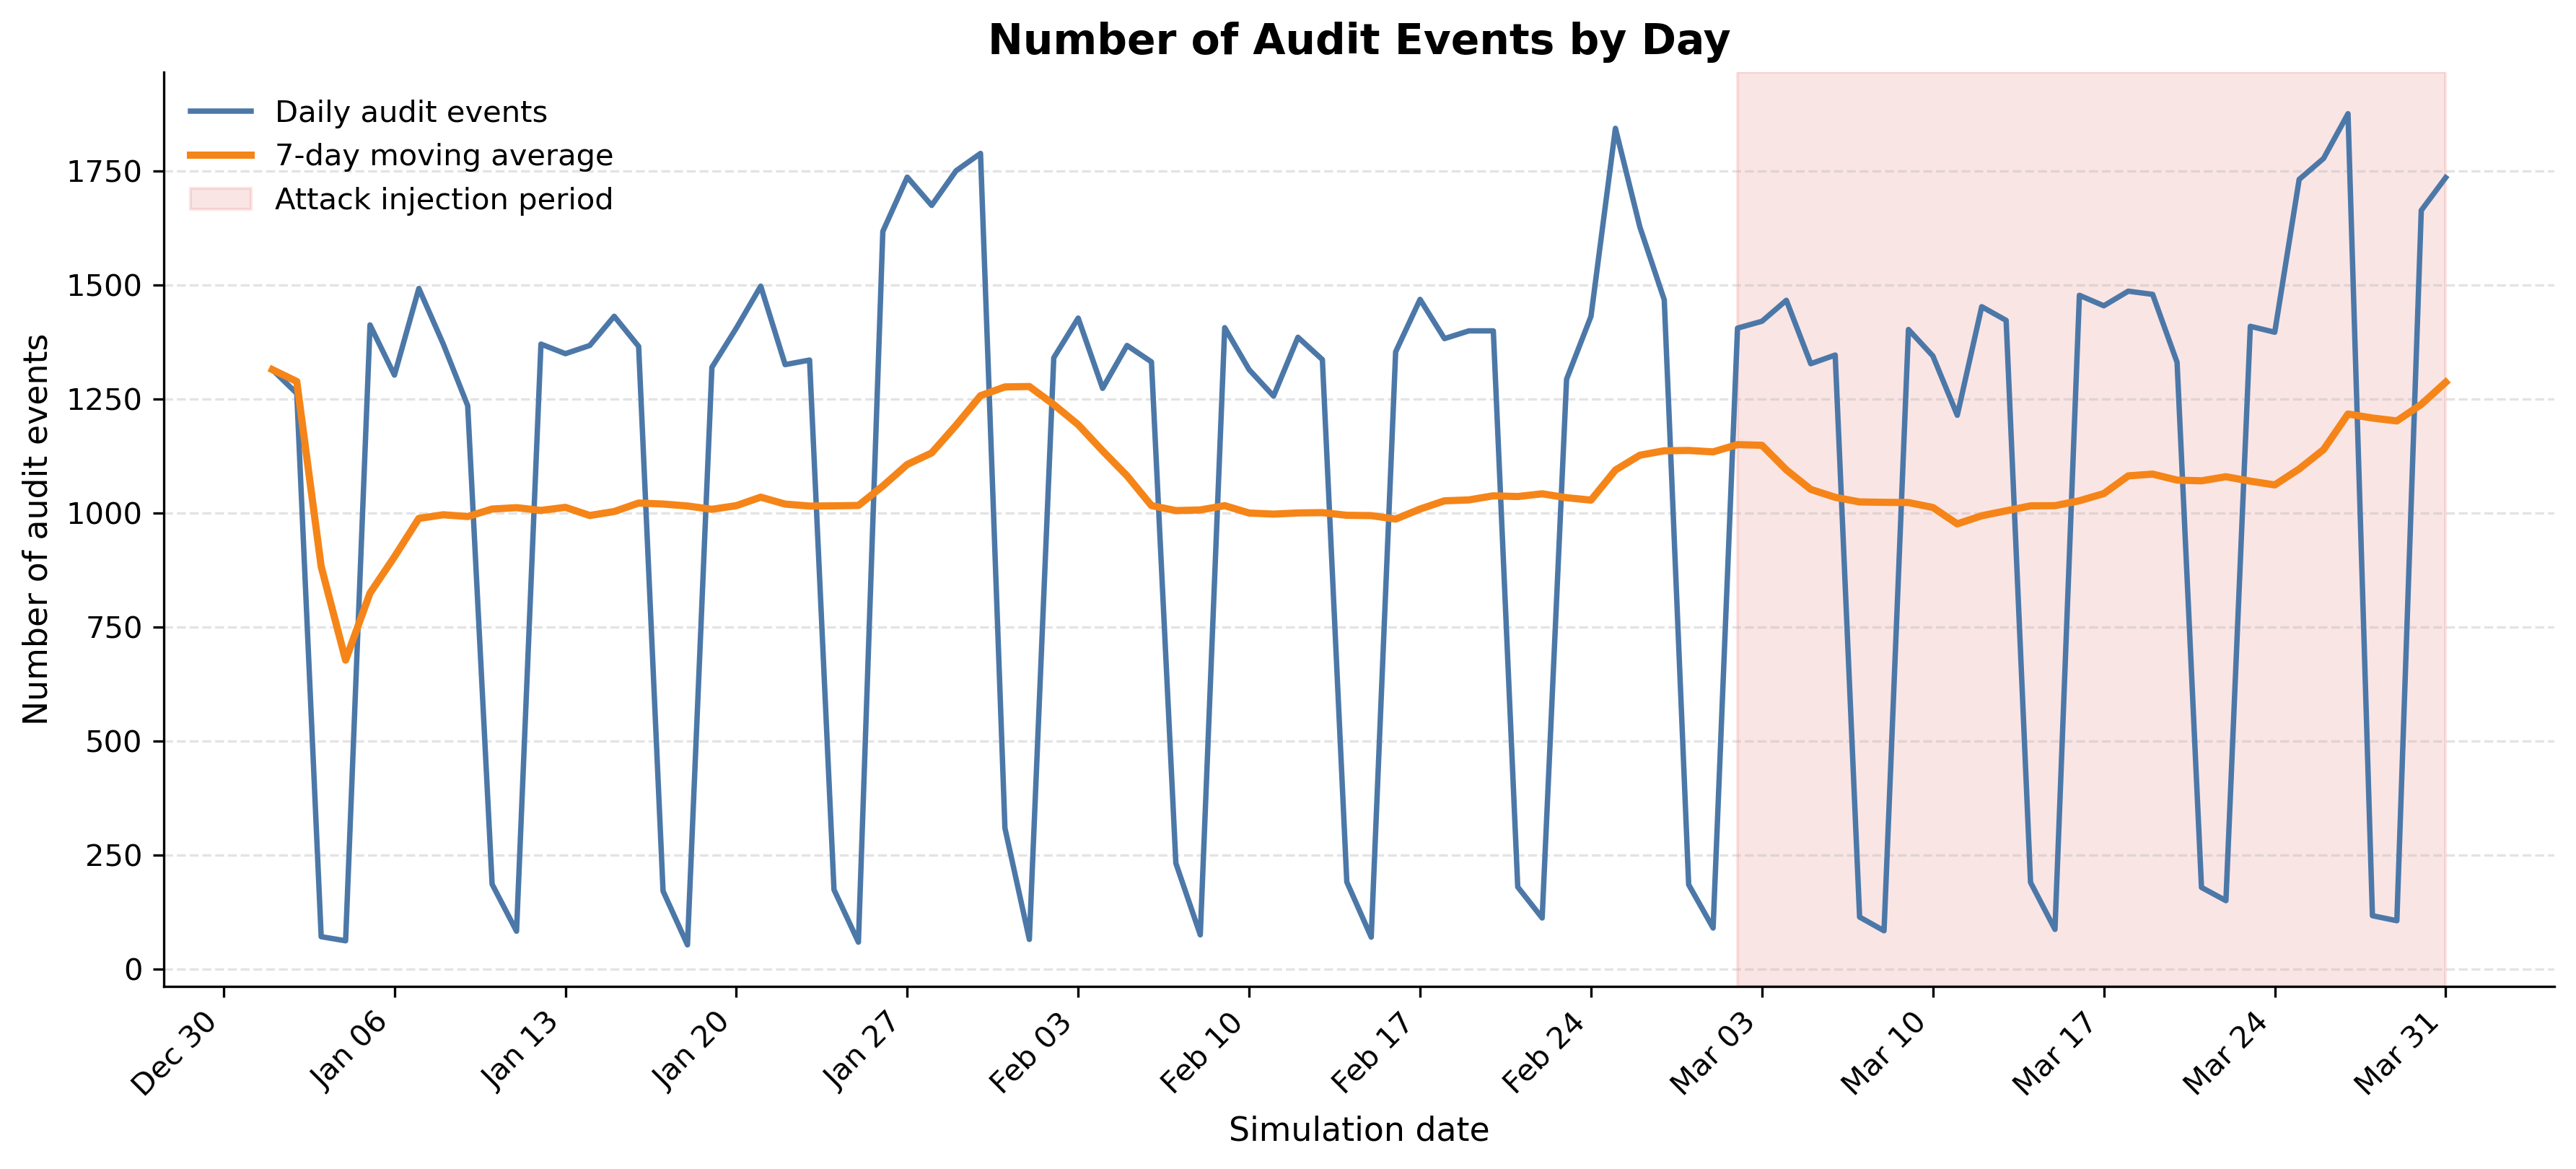

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Đọc file CSV
df = pd.read_csv("summary_by_day.csv")

# Chuyển cột ngày sang datetime
df["sim_date"] = pd.to_datetime(df["sim_date"])

# Sắp xếp theo ngày
df = df.sort_values("sim_date")

# Tính trung bình trượt 7 ngày để đường mượt hơn
df["rolling_7d"] = df["total_events"].rolling(window=7, min_periods=1).mean()

# Giai đoạn attack
attack_start = pd.to_datetime("2026-03-02")
attack_end = pd.to_datetime("2026-03-31")

# Tạo hình
plt.figure(figsize=(12, 5.5), dpi=300)

# Vẽ số audit events theo ngày
plt.plot(
    df["sim_date"],
    df["total_events"],
    color="#4C78A8",
    linewidth=1.8,
    label="Daily audit events"
)

# Vẽ đường trung bình 7 ngày
plt.plot(
    df["sim_date"],
    df["rolling_7d"],
    color="#F58518",
    linewidth=2.4,
    label="7-day moving average"
)

# Tô vùng attack
plt.axvspan(
    attack_start,
    attack_end,
    color="#E45756",
    alpha=0.15,
    label="Attack injection period"
)

# Định dạng tiêu đề và trục
plt.title("Number of Audit Events by Day", fontsize=14, fontweight="bold")
plt.xlabel("Simulation date", fontsize=11)
plt.ylabel("Number of audit events", fontsize=11)

# Định dạng ngày trên trục X
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45, ha="right")

# Lưới nhẹ
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Bỏ viền trên/phải cho đẹp
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Chú giải
plt.legend(frameon=False, fontsize=10)

# Căn layout
plt.tight_layout()

# Lưu hình
plt.savefig("figure_6_audit_events_by_day.png", bbox_inches="tight")
plt.show()